# NASA GISTEMP Geospatial Analysis
### Mapping Global Temperature Anomalies with GeoPandas and Cartopy

**Author:** Emma Follis  
**Data source:** [NASA GISS Surface Temperature Analysis (GISTEMP v4)](https://data.giss.nasa.gov/gistemp/)  
**Tools:** Python, pandas, numpy, GeoPandas, Cartopy, matplotlib  
**Last updated:** June 2026

---

## Overview
This project extends the temporal analysis from Project 2 into spatial analysis -
mapping *where* on Earth warming is most dramatic, not just *when*. Using NASA's
GISS gridded temperature dataset, we analyze temperature anomalies broken down
by latitude and longitude across the full global surface.

The analysis covers four questions:
1. Which regions of Earth have warmed the most since 1880?
2. How does warming differ between the Northern and Southern hemispheres?
3. Which latitude bands show the strongest warming signal?
4. How has the spatial pattern of warming changed over time?

## Setup
### Installing and importing libraries

In [ ]:
# Install libraries not pre-installed in Colab
!pip install cartopy geopandas --quiet

from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"GeoPandas version: {gpd.__version__}")

All libraries imported successfully
GeoPandas version: 1.1.3


### Loading the gridded temperature data

In [ ]:
from google.colab import files

print("Please upload the NASA GISS Zonal temperature file.")
print("Download it from: https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv")
uploaded = files.upload()

Please upload the NASA GISS Zonal temperature file.
Download it from: https://data.giss.nasa.gov/gistemp/tabledata_v4/ZonAnn.Ts+dSST.csv


Saving ZonAnn.Ts+dSST.csv to ZonAnn.Ts+dSST (1).csv


In [ ]:
# Load with no header — we'll assign column names manually
df_raw = pd.read_csv('ZonAnn.Ts+dSST.csv', skiprows=1, header=None)

# Assign correct column names based on NASA GISS zonal file structure
df_raw.columns = [
    'Year', 'Glob', 'NHem', 'SHem',
    '24N-90N', '24S-24N', '90S-24S',
    '64N-90N', '44N-64N', '24N-44N',
    'EQU-24N', '24S-EQU', '44S-24S',
    '64S-44S', '90S-64S'
]

print("Fixed data shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())
print("\nFirst 5 rows:")
print(df_raw.head())

Fixed data shape: (146, 15)

Column names:
['Year', 'Glob', 'NHem', 'SHem', '24N-90N', '24S-24N', '90S-24S', '64N-90N', '44N-64N', '24N-44N', 'EQU-24N', '24S-EQU', '44S-24S', '64S-44S', '90S-64S']

First 5 rows:
   Year  Glob  NHem  SHem  24N-90N  24S-24N  90S-24S  64N-90N  44N-64N  \
0  1880 -0.18 -0.30 -0.05    -0.40    -0.14    -0.01    -0.78    -0.51   
1  1881 -0.09 -0.19  0.00    -0.36     0.09    -0.07    -0.83    -0.46   
2  1882 -0.11 -0.22 -0.01    -0.31    -0.06     0.01    -1.33    -0.28   
3  1883 -0.18 -0.29 -0.07    -0.35    -0.18    -0.01    -0.11    -0.56   
4  1884 -0.29 -0.43 -0.15    -0.60    -0.16    -0.14    -1.24    -0.65   

   24N-44N  EQU-24N  24S-EQU  44S-24S  64S-44S  90S-64S  
0    -0.31    -0.16    -0.12    -0.04     0.05     0.69  
1    -0.23     0.09     0.09    -0.05    -0.07     0.62  
2    -0.17    -0.06    -0.06     0.01     0.04     0.65  
3    -0.28    -0.19    -0.16    -0.04     0.07     0.52  
4    -0.48    -0.14    -0.18    -0.19    -0.02     0.

### Cleaning and preparing the data

In [ ]:
# Convert all columns to numeric
df = df_raw.copy()
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows where Year is missing
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

# Drop 2026 if present (incomplete year)
df = df[df['Year'] <= 2025]

# Verify
print(f"Clean data shape: {df.shape}")
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nSample — Arctic (64N-90N) warming:")
print(df[['Year', 'Glob', '64N-90N']].tail(10))

Clean data shape: (146, 15)
Year range: 1880 to 2025

Missing values per column:
Year       0
Glob       0
NHem       0
SHem       0
24N-90N    0
24S-24N    0
90S-24S    0
64N-90N    0
44N-64N    0
24N-44N    0
EQU-24N    0
24S-EQU    0
44S-24S    0
64S-44S    0
90S-64S    0
dtype: int64

Sample — Arctic (64N-90N) warming:
     Year  Glob  64N-90N
136  2016  1.01     3.26
137  2017  0.92     2.51
138  2018  0.85     2.17
139  2019  0.98     2.78
140  2020  1.01     2.86
141  2021  0.85     2.08
142  2022  0.89     2.36
143  2023  1.17     2.58
144  2024  1.28     2.91
145  2025  1.19     2.98


## Visualization 1: Warming by Latitude Band
### Which regions of Earth have warmed the most since 1880?
Comparing temperature anomaly trends across all latitude bands reveals
the dramatic difference between Arctic amplification and tropical warming.

Total warming by latitude band (recent 2015-2025 vs early 1880-1890):
Arctic (64°N-90°N): +3.68°C
N. High Latitudes (44°N-64°N): +2.06°C
N. Mid Latitudes (24°N-44°N): +1.54°C
N. Tropics (0°-24°N): +1.01°C
S. Tropics (0°-24°S): +0.96°C
S. Mid Latitudes (24°S-44°S): +0.94°C
S. High Latitudes (44°S-64°S): +0.50°C
Antarctic (64°S-90°S): +0.15°C


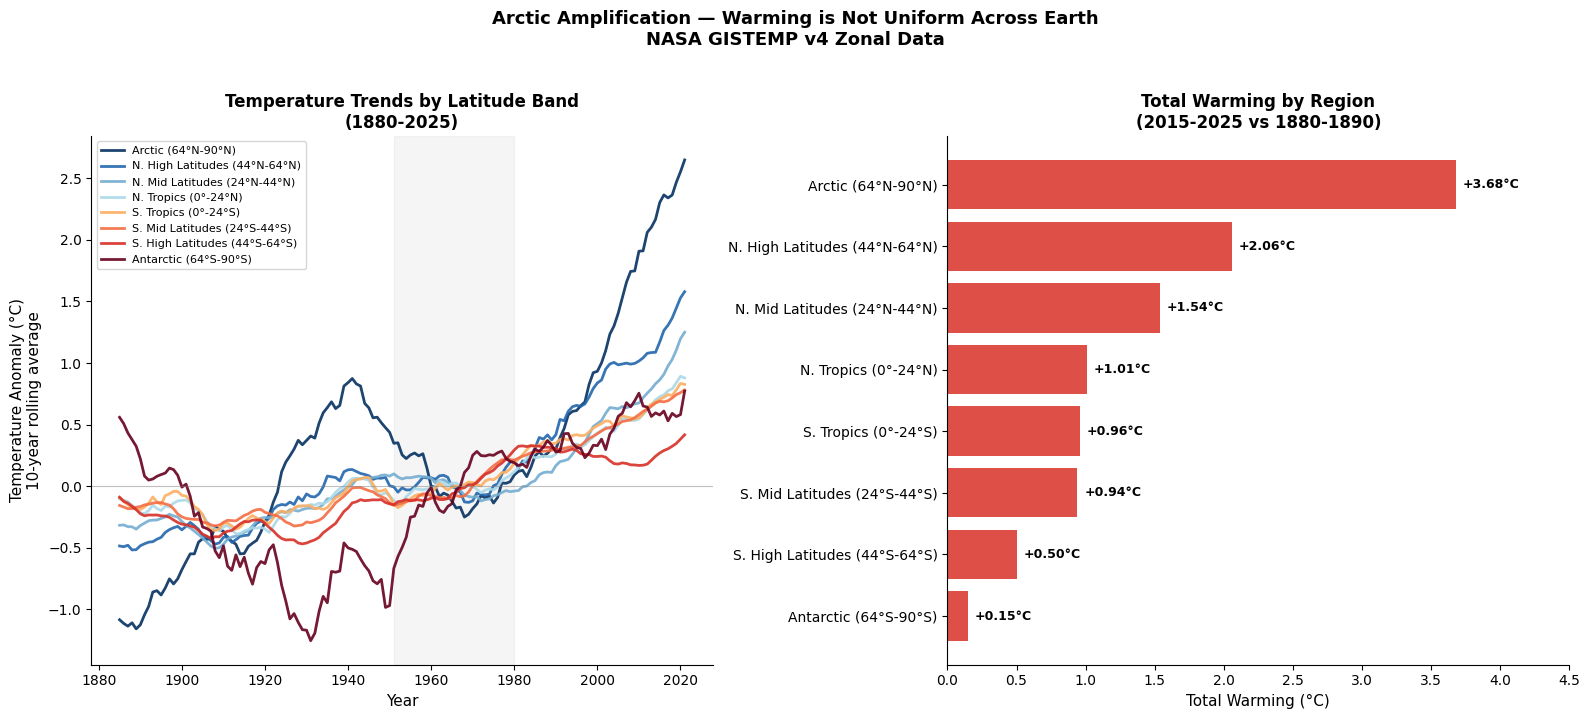

Chart saved as lat_band_warming.png


In [ ]:
# Define latitude bands from north to south with descriptive names
lat_bands = {
    '64N-90N': 'Arctic (64°N-90°N)',
    '44N-64N': 'N. High Latitudes (44°N-64°N)',
    '24N-44N': 'N. Mid Latitudes (24°N-44°N)',
    'EQU-24N': 'N. Tropics (0°-24°N)',
    '24S-EQU': 'S. Tropics (0°-24°S)',
    '44S-24S': 'S. Mid Latitudes (24°S-44°S)',
    '64S-44S': 'S. High Latitudes (44°S-64°S)',
    '90S-64S': 'Antarctic (64°S-90°S)'
}

# Calculate 10-year rolling averages for each band
df_smooth = df.copy()
for band in lat_bands.keys():
    df_smooth[f'{band}_smooth'] = df[band].rolling(window=10, center=True).mean()

# Calculate total warming for each band (recent 10 years vs first 10 years)
recent = df[df['Year'] >= 2015][list(lat_bands.keys())].mean()
early = df[df['Year'] <= 1890][list(lat_bands.keys())].mean()
total_warming = (recent - early).round(2)

print("Total warming by latitude band (recent 2015-2025 vs early 1880-1890):")
for band, name in lat_bands.items():
    print(f"{name}: +{total_warming[band]:.2f}°C")

# Create the chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Color palette from blue (south) to red (north)
colors = ['#053061', '#2166ac', '#74add1', '#abd9e9',
          '#fdae61', '#f46d43', '#d73027', '#67001f']

# Left chart: time series for each latitude band
for (band, name), color in zip(lat_bands.items(), colors):
    smooth_col = f'{band}_smooth'
    ax1.plot(df_smooth['Year'], df_smooth[smooth_col],
             color=color, linewidth=2, label=name, alpha=0.9)

ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax1.axvspan(1951, 1980, alpha=0.08, color='gray')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Temperature Anomaly (°C)\n10-year rolling average', fontsize=11)
ax1.set_title('Temperature Trends by Latitude Band\n(1880-2025)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
sns.despine(ax=ax1)

# Right chart: total warming bar chart
warming_df = pd.DataFrame({
    'Region': list(lat_bands.values()),
    'Warming': [total_warming[b] for b in lat_bands.keys()]
}).sort_values('Warming', ascending=True)

colors_bar = ['#d73027' if v > 0 else '#4575b4' for v in warming_df['Warming']]
bars = ax2.barh(warming_df['Region'], warming_df['Warming'],
                color=colors_bar, alpha=0.85)

for bar, val in zip(bars, warming_df['Warming']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'+{val:.2f}°C', va='center', fontsize=9, fontweight='bold')

ax2.axvline(x=0, color='gray', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Total Warming (°C)', fontsize=11)
ax2.set_title('Total Warming by Region\n(2015-2025 vs 1880-1890)',
              fontsize=12, fontweight='bold')
ax2.set_xlim(0, 4.5)
sns.despine(ax=ax2)

plt.suptitle('Arctic Amplification — Warming is Not Uniform Across Earth\nNASA GISTEMP v4 Zonal Data',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('lat_band_warming.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as lat_band_warming.png")

## Visualization 2: Global Warming Map
### Projecting temperature anomalies onto a world map
Mapping the latitude band warming data onto a geographic projection
reveals the spatial story of climate change - where on Earth the
signal is strongest and where it is weakest.

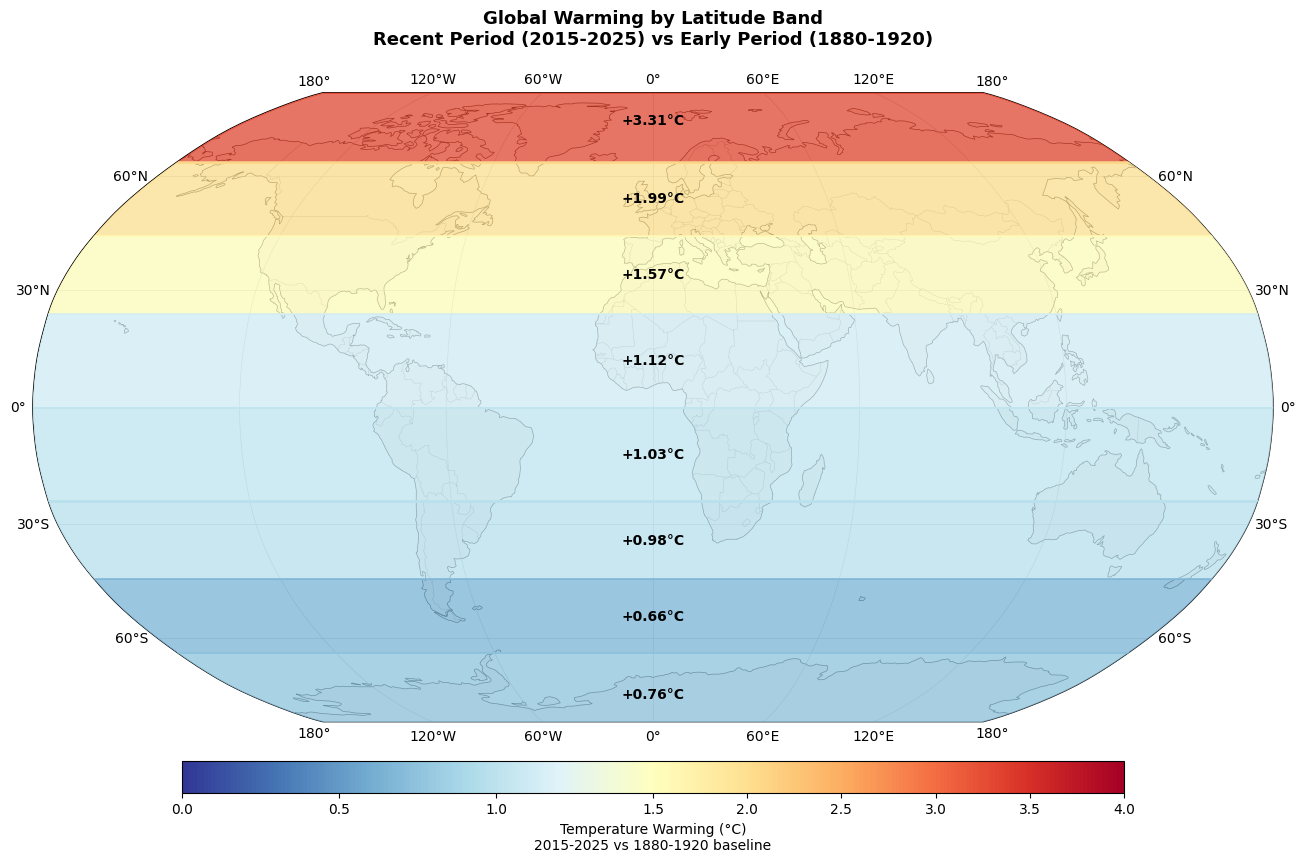

Chart saved as global_warming_map.png


In [ ]:
# Calculate average anomaly for two periods to show change
early_period = df[df['Year'] <= 1920][list(lat_bands.keys())].mean()
recent_period = df[df['Year'] >= 2015][list(lat_bands.keys())].mean()
warming = (recent_period - early_period).round(3)

# Define latitude band centers and boundaries for mapping
band_info = {
    '64N-90N': (77, 64, 90),    # (center_lat, south_bound, north_bound)
    '44N-64N': (54, 44, 64),
    '24N-44N': (34, 24, 44),
    'EQU-24N': (12, 0, 24),
    '24S-EQU': (-12, -24, 0),
    '44S-24S': (-34, -44, -24),
    '64S-44S': (-54, -64, -44),
    '90S-64S': (-77, -90, -64)
}

# Create figure with Cartopy map projection
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

# Add map features
ax.add_feature(cfeature.OCEAN, facecolor='lightcyan', alpha=0.3, zorder=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5, zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)

# Color normalization centered on zero
norm = TwoSlopeNorm(vmin=0, vcenter=1.5, vmax=4.0)
cmap = plt.cm.RdYlBu_r

# Draw colored bands for each latitude zone
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

for band, (center, south, north) in band_info.items():
    warming_val = warming[band]
    color = cmap(norm(warming_val))

    # Draw the latitude band as a filled rectangle
    ax.fill_between(
        [-180, 180],
        [south, south],
        [north, north],
        color=color,
        alpha=0.75,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    # Add warming value label
    ax.text(
        0, center,
        f'+{warming_val:.2f}°C',
        transform=ccrs.PlateCarree(),
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color='black',
        zorder=5
    )

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal',
                    pad=0.05, shrink=0.6, aspect=30)
cbar.set_label('Temperature Warming (°C)\n2015-2025 vs 1880-1920 baseline',
               fontsize=10)

ax.set_global()
ax.set_title(
    'Global Warming by Latitude Band\nRecent Period (2015-2025) vs Early Period (1880-1920)',
    fontsize=13, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('global_warming_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as global_warming_map.png")

## Visualization 3: Northern vs Southern Hemisphere Comparison
### How differently are the two hemispheres warming?
The Northern Hemisphere warms faster than the Southern Hemisphere
due to differences in land mass, ocean coverage, and sea ice.
This visualization quantifies that difference over 145 years.

=== HEMISPHERE COMPARISON STATISTICS ===

Recent decade (2015-2025) averages:
Northern Hemisphere: +1.288°C
Southern Hemisphere: +0.718°C
Global average: +1.005°C
N-S difference: +0.570°C

Early decade (1880-1890) averages:
Northern Hemisphere: -0.324°C
Southern Hemisphere: -0.135°C
Global average: -0.229°C

Total warming since 1880-1890:
Northern Hemisphere: +1.612°C
Southern Hemisphere: +0.854°C


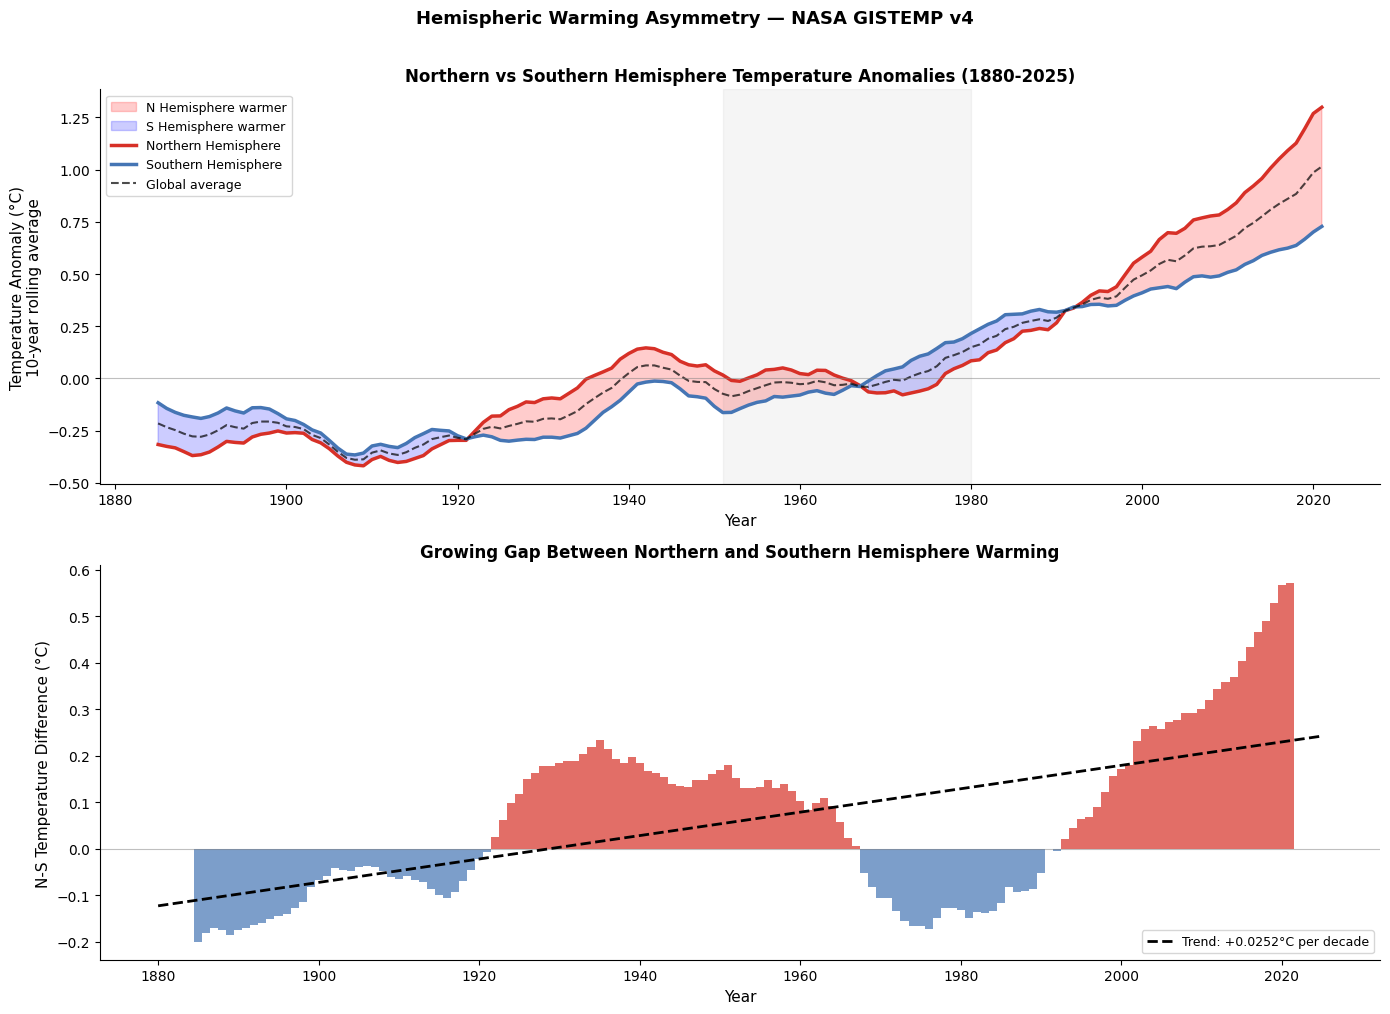

Chart saved as hemisphere_comparison.png


In [ ]:
# Calculate rolling averages for hemispheres
df['NHem_smooth'] = df['NHem'].rolling(window=10, center=True).mean()
df['SHem_smooth'] = df['SHem'].rolling(window=10, center=True).mean()
df['Glob_smooth'] = df['Glob'].rolling(window=10, center=True).mean()
df['Diff'] = df['NHem'] - df['SHem']
df['Diff_smooth'] = df['Diff'].rolling(window=10, center=True).mean()

# Statistics
print("=== HEMISPHERE COMPARISON STATISTICS ===")
print(f"\nRecent decade (2015-2025) averages:")
recent = df[df['Year'] >= 2015]
print(f"Northern Hemisphere: +{recent['NHem'].mean():.3f}°C")
print(f"Southern Hemisphere: +{recent['SHem'].mean():.3f}°C")
print(f"Global average: +{recent['Glob'].mean():.3f}°C")
print(f"N-S difference: +{recent['Diff'].mean():.3f}°C")

print(f"\nEarly decade (1880-1890) averages:")
early = df[df['Year'] <= 1890]
print(f"Northern Hemisphere: {early['NHem'].mean():.3f}°C")
print(f"Southern Hemisphere: {early['SHem'].mean():.3f}°C")
print(f"Global average: {early['Glob'].mean():.3f}°C")

print(f"\nTotal warming since 1880-1890:")
print(f"Northern Hemisphere: +{(recent['NHem'].mean() - early['NHem'].mean()):.3f}°C")
print(f"Southern Hemisphere: +{(recent['SHem'].mean() - early['SHem'].mean()):.3f}°C")

# Create the chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: hemisphere trends
ax1.fill_between(df['Year'], df['NHem_smooth'], df['SHem_smooth'],
                 where=df['NHem_smooth'] >= df['SHem_smooth'],
                 alpha=0.2, color='red', label='N Hemisphere warmer')
ax1.fill_between(df['Year'], df['NHem_smooth'], df['SHem_smooth'],
                 where=df['NHem_smooth'] < df['SHem_smooth'],
                 alpha=0.2, color='blue', label='S Hemisphere warmer')

ax1.plot(df['Year'], df['NHem_smooth'],
         color='#d73027', linewidth=2.5, label='Northern Hemisphere')
ax1.plot(df['Year'], df['SHem_smooth'],
         color='#4575b4', linewidth=2.5, label='Southern Hemisphere')
ax1.plot(df['Year'], df['Glob_smooth'],
         color='black', linewidth=1.5, linestyle='--',
         label='Global average', alpha=0.7)

ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax1.axvspan(1951, 1980, alpha=0.08, color='gray')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Temperature Anomaly (°C)\n10-year rolling average', fontsize=11)
ax1.set_title('Northern vs Southern Hemisphere Temperature Anomalies (1880-2025)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
sns.despine(ax=ax1)

# Bottom chart: difference between hemispheres
colors_diff = ['#d73027' if v >= 0 else '#4575b4' for v in df['Diff_smooth']]
ax2.bar(df['Year'], df['Diff_smooth'], color=colors_diff, alpha=0.7, width=1.0)
ax2.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)

# Add trend line for the difference
valid = df.dropna(subset=['Diff_smooth'])
slope, intercept, r_value, p_value, std_err = stats.linregress(
    valid['Year'], valid['Diff_smooth']
)
trend = slope * df['Year'] + intercept
ax2.plot(df['Year'], trend, color='black', linewidth=2,
         linestyle='--', label=f'Trend: +{slope*10:.4f}°C per decade')

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('N-S Temperature Difference (°C)', fontsize=11)
ax2.set_title('Growing Gap Between Northern and Southern Hemisphere Warming',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

plt.suptitle('Hemispheric Warming Asymmetry — NASA GISTEMP v4',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('hemisphere_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as hemisphere_comparison.png")

## Visualization 4: Polar Amplification Heatmap
### How has warming in each latitude band changed decade by decade?
A heatmap showing temperature anomalies for every latitude band
across every decade - revealing the full spatial and temporal
pattern of climate change in one visualization.

Decade averages by latitude band:
        64N-90N  44N-64N  24N-44N  EQU-24N  24S-EQU  44S-24S  64S-44S  90S-64S
Decade                                                                        
1880     -1.085   -0.486   -0.318   -0.103   -0.089   -0.157   -0.091    0.559
1890     -0.884   -0.416   -0.262   -0.198   -0.149   -0.134   -0.241    0.094
1900     -0.426   -0.405   -0.422   -0.229   -0.234   -0.293   -0.390   -0.332
1910     -0.547   -0.401   -0.375   -0.364   -0.298   -0.238   -0.287   -0.577
1920      0.195   -0.154   -0.216   -0.251   -0.211   -0.291   -0.437   -0.932
1930      0.638    0.082   -0.103   -0.126   -0.174   -0.216   -0.353   -0.947
1940      0.636    0.084    0.058    0.047    0.070   -0.037   -0.115   -0.688
1950      0.253   -0.030    0.068   -0.055   -0.104   -0.113   -0.120   -0.252
1960     -0.124   -0.007    0.010    0.025   -0.007   -0.096   -0.062   -0.142
1970     -0.137    0.003   -0.078   -0.031    0.052    0.165    0.130    0.250
1980      0.246   

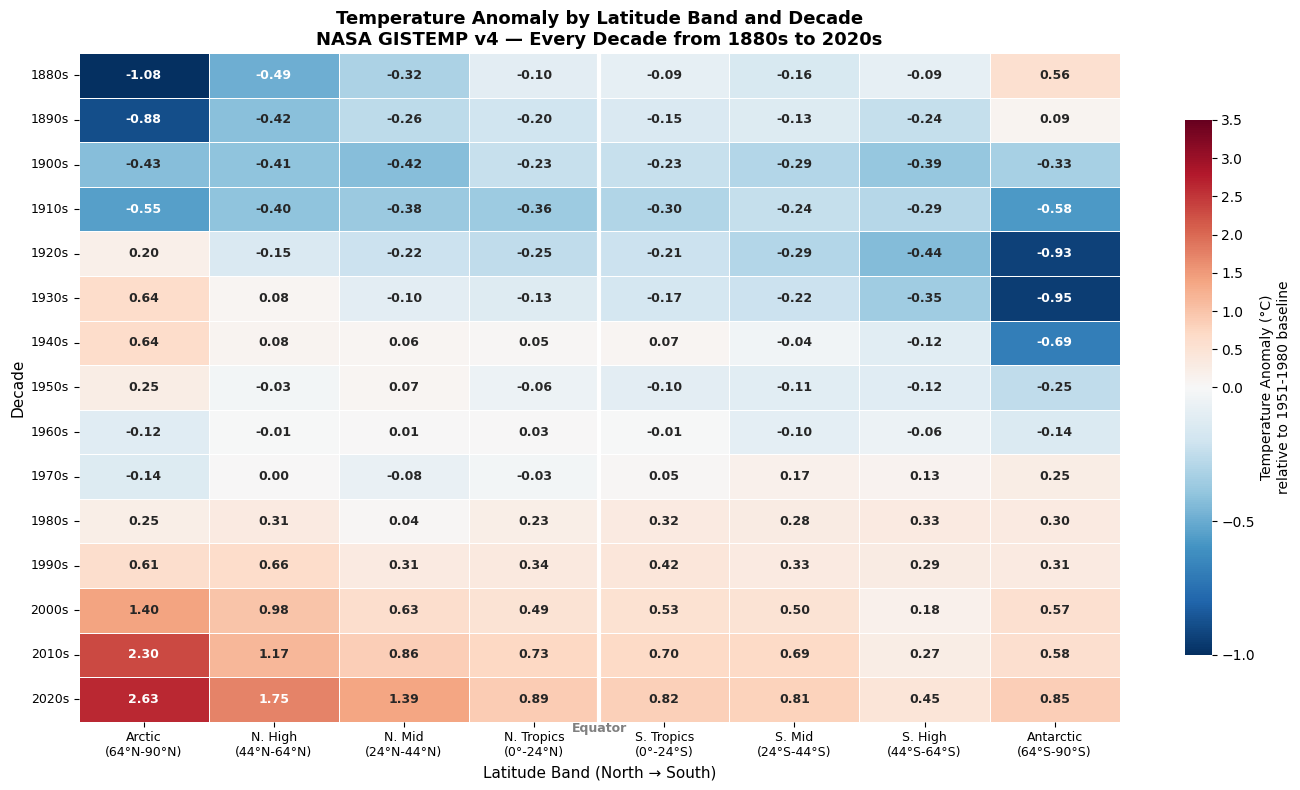

Chart saved as polar_amplification_heatmap.png


In [ ]:
# Build decade averages for each latitude band
zone_cols = list(lat_bands.keys())
df['Decade'] = (df['Year'] // 10) * 10

decade_zone = df.groupby('Decade')[zone_cols].mean().round(3)

print("Decade averages by latitude band:")
print(decade_zone.to_string())

# Rename columns to readable labels for the heatmap
readable_cols = {
    '64N-90N': 'Arctic\n(64°N-90°N)',
    '44N-64N': 'N. High\n(44°N-64°N)',
    '24N-44N': 'N. Mid\n(24°N-44°N)',
    'EQU-24N': 'N. Tropics\n(0°-24°N)',
    '24S-EQU': 'S. Tropics\n(0°-24°S)',
    '44S-24S': 'S. Mid\n(24°S-44°S)',
    '64S-44S': 'S. High\n(44°S-64°S)',
    '90S-64S': 'Antarctic\n(64°S-90°S)'
}

heatmap_data = decade_zone.rename(columns=readable_cols)

# Create the heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Diverging colormap centered on zero
norm = TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=3.5)

sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    norm=norm,
    ax=ax,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'label': 'Temperature Anomaly (°C)\nrelative to 1951-1980 baseline',
        'shrink': 0.8
    }
)

# Add a horizontal line separating Northern and Southern hemispheres
ax.axvline(x=4, color='white', linewidth=3, zorder=5)
ax.text(4, len(decade_zone) + 0.3, 'Equator', ha='center', va='bottom',
        fontsize=9, color='gray', fontweight='bold')

ax.set_xlabel('Latitude Band (North → South)', fontsize=11)
ax.set_ylabel('Decade', fontsize=11)
ax.set_title(
    'Temperature Anomaly by Latitude Band and Decade\nNASA GISTEMP v4 — Every Decade from 1880s to 2020s',
    fontsize=13, fontweight='bold'
)

# Rotate x labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
ax.set_yticklabels([f"{int(y.get_text())}s" for y in ax.get_yticklabels()],
                   rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('polar_amplification_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as polar_amplification_heatmap.png")